# Softball Ratings — Exploration

KenPom-style opponent-adjusted offensive/defensive ratings for D1 college softball, sourced from Massey.

First run scrapes Massey and caches to `data/games.csv`; subsequent runs use the cache. Pass `refresh=True` to re-scrape.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.insert(0, '.')

import pandas as pd
from softballratings.scrape import fetch_raw, filter_to_core
from softballratings.ratings import fit_ratings

## 1. Load games

In [2]:
raw = fetch_raw()  # add refresh=True to re-pull from Massey
games = filter_to_core(raw, min_games=15)  # iteratively prune weakly-connected (non-D1) teams
print(f'raw games: {len(raw)}  ({len(set(raw.home_team)|set(raw.away_team))} teams)')
print(f'core games: {len(games)}  ({len(set(games.home_team)|set(games.away_team))} teams)')
print('date range:', games['date'].min().date(), '->', games['date'].max().date())
print('neutral-site games:', int(games['neutral'].sum()))
games.head()

raw games: 6219  (348 teams)
core games: 6123  (308 teams)
date range: 2026-02-05 -> 2026-04-15
neutral-site games: 1538


,date,home_team,away_team,home_score,away_score,neutral,location
0,2026-02-05,UCF,Boston Univ,13,0,False,NaN
1,2026-02-05,CS Fullerton,Mississippi,5,4,False,NaN
2,2026-02-05,CS Fullerton,Mississippi,9,11,False,NaN
3,2026-02-05,North Florida,Auburn,11,3,False,NaN
4,2026-02-05,Baylor,Mississippi St,0,10,False,NaN


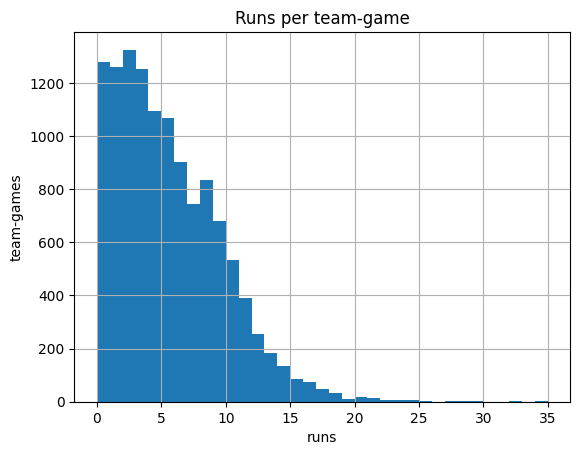

mean runs/team-game: 5.153


In [3]:
# Score distribution sanity check
import matplotlib.pyplot as plt
all_scores = pd.concat([games['home_score'], games['away_score']])
all_scores.hist(bins=range(0, int(all_scores.max()) + 2))
plt.xlabel('runs'); plt.ylabel('team-games'); plt.title('Runs per team-game')
plt.show()
print('mean runs/team-game:', all_scores.mean().round(3))

## 2. Fit ratings (no blowout adjustment)

In [4]:
r = fit_ratings(games)
print(f'converged={r.converged}  iters={r.n_iter}  HFA={r.hfa:.3f} runs  league_mean={r.league_mean:.3f}')
table = pd.DataFrame({'Off': r.off, 'Def': r.def_})
table['Net'] = table['Off'] - table['Def']
table.sort_values('Net', ascending=False).head(25).round(2)

converged=True  iters=47  HFA=0.129 runs  league_mean=5.153


,Off,Def,Net
Oklahoma,7.73,-4.43,12.15
Arkansas,5.93,-4.98,10.92
Texas Tech,5.88,-4.82,10.70
UCLA,7.70,-2.84,10.53
Texas,5.36,-4.84,10.20
Florida,5.48,-4.41,9.89
Nebraska,3.87,-5.66,9.53
Alabama,3.85,-5.26,9.12
Tennessee,3.32,-5.79,9.11
Georgia,4.69,-3.95,8.64


In [5]:
# Bottom of the league — sniff check
table.sort_values('Net', ascending=False).tail(10).round(2)

,Off,Def,Net
Mercyhurst,-3.49,3.91,-7.40
New Haven,-4.40,3.23,-7.63
Tennessee St,-2.93,4.86,-7.80
St Peter's,-3.53,4.29,-7.82
Morgan St,-3.89,4.31,-8.20
Niagara,-3.80,4.81,-8.61
St Francis PA,-2.87,5.80,-8.66
Alabama A&M,-2.08,7.21,-9.30
MD E Shore,-5.41,4.51,-9.92
MS Valley St,-5.95,8.16,-14.11


## 3. With blowout adjustment

Downweights games by `k / (k + max(0, |margin| - cap))`. Margin within `cap` runs counts fully; bigger margins are softened so a single 15–0 result doesn't dominate.

In [6]:
r2 = fit_ratings(games, blowout_cap=8, blowout_k=4)
print(f'converged={r2.converged}  iters={r2.n_iter}  HFA={r2.hfa:.3f}')
t2 = pd.DataFrame({'Off': r2.off, 'Def': r2.def_})
t2['Net'] = t2['Off'] - t2['Def']
t2.sort_values('Net', ascending=False).head(25).round(2)

converged=True  iters=48  HFA=0.233


,Off,Def,Net
Oklahoma,5.64,-4.16,9.80
Arkansas,5.21,-4.48,9.69
Texas Tech,4.92,-4.64,9.55
Texas,5.01,-4.20,9.22
UCLA,7.04,-2.12,9.16
Nebraska,3.50,-5.15,8.65
Florida,4.51,-4.01,8.51
Alabama,3.44,-4.89,8.33
Tennessee,2.91,-5.31,8.22
Georgia,4.16,-3.67,7.82


In [7]:
# Compare top-25 movement: which teams shift most when blowouts are downweighted?
compare = pd.DataFrame({'Net_raw': table['Net'], 'Net_blowout': t2['Net']})
compare['delta'] = compare['Net_blowout'] - compare['Net_raw']
compare.reindex(table.sort_values('Net', ascending=False).head(25).index).round(2)

,Net_raw,Net_blowout,delta
Oklahoma,12.15,9.80,-2.35
Arkansas,10.92,9.69,-1.23
Texas Tech,10.70,9.55,-1.15
UCLA,10.53,9.16,-1.37
Texas,10.20,9.22,-0.98
Florida,9.89,8.51,-1.38
Nebraska,9.53,8.65,-0.88
Alabama,9.12,8.33,-0.78
Tennessee,9.11,8.22,-0.90
Georgia,8.64,7.82,-0.82


## 4. Spot-check a team

In [8]:
team = 'Oklahoma'
tg = games[(games['home_team'] == team) | (games['away_team'] == team)].copy()
tg['team_score'] = tg.apply(lambda g: g['home_score'] if g['home_team'] == team else g['away_score'], axis=1)
tg['opp_score']  = tg.apply(lambda g: g['away_score'] if g['home_team'] == team else g['home_score'], axis=1)
tg['opp']        = tg.apply(lambda g: g['away_team'] if g['home_team'] == team else g['home_team'], axis=1)
tg['venue']      = tg.apply(lambda g: 'N' if g['neutral'] else ('H' if g['home_team'] == team else 'A'), axis=1)
print(f'{team}: {len(tg)} games   Off={r.off[team]:.2f}  Def={r.def_[team]:.2f}')
tg[['date','opp','venue','team_score','opp_score']].sort_values('date').reset_index(drop=True)

Oklahoma: 44 games   Off=7.73  Def=-4.43


,date,opp,venue,team_score,opp_score
0,2026-02-05,Arizona St,A,2,1
1,2026-02-06,Arizona,A,6,11
2,2026-02-07,Arizona,A,21,3
3,2026-02-08,Arizona,A,5,4
4,2026-02-13,Montana,N,17,0
5,2026-02-13,New Mexico St,A,18,6
6,2026-02-14,Minnesota,N,12,2
7,2026-02-14,Idaho St,N,10,1
8,2026-02-15,UTEP,A,34,0
9,2026-02-19,San Diego St,N,10,2


## 5. Production ratings — full league

Uses `softballratings.rate.build_ratings()` (ridge λ=3, recency half-life 45 days). The full table is rendered scrollable so you can browse top to bottom.

In [ ]:
from softballratings.rate import build_ratings, predict_game

ratings = build_ratings(games, save_to=None)
print(f"HFA = {ratings['hfa'].iloc[0]:.3f} runs   sigma = {ratings['sigma'].iloc[0]:.3f}   league_mean = {ratings['league_mean'].iloc[0]:.3f}")
print(f"{len(ratings)} teams")

# Show the full table — Jupyter will render it scrollable.
pd.set_option("display.max_rows", None)
ratings[["rank", "team", "n_games", "net", "off", "def", "p_beat_avg"]].round(3)

In [10]:
# Example: head-to-head matchup prediction
predict_game(ratings, "Oklahoma", "Texas", neutral=False)

{'home': 'Oklahoma',
 'away': 'Texas',
 'neutral': False,
 'pred_home_score': 7.667807544315759,
 'pred_away_score': 5.315964758369889,
 'pred_margin': 2.351842785945869,
 'p_home_wins': 0.6949525990291902}